In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [18]:

# works out correlation matrix for returns in window size K ending at t - so up to time t
def correlation_matrix(returns, t, K, eps=0.0, active=None):
    t = pd.to_datetime(t)
    # 1. Slice the window
    window = returns.loc[t - pd.Timedelta(days=K*1.5): t]
    # 2. Filter for active and non-zero stocks
    if active is not None:
        window = window[active]
    if eps == 0.0:
        window = window.loc[:, (window.fillna(0.0) != 0.0).any(axis=0)]
    else:
        window = window.loc[:, (window.fillna(0.0).abs() > eps).any(axis=0)]

    active_cols = window.columns.tolist()
    # 3. Vectorized Math (NumPy is faster here)
    X = window.values # Shape: (Time, Stocks)
    X = np.nan_to_num(X) # Handle any remaining NaNs

    centered = X - np.mean(X, axis=0)
    # matrix multiplication: (Stocks, Time) @ (Time, Stocks) -> (Stocks, Stocks)
    cov = (centered.T @ centered) / (X.shape[0] - 1)

    std = np.sqrt(np.diag(cov))
    # Outer product of standard deviations with epsilon for stability
    denominator = np.outer(std, std) + 1e-9
    corr = cov / denominator

    return np.clip(corr, -1.0, 1.0), active_cols # Clip to ensure valid corr range

    # corr_matrix = window.corr().values
    # corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    # return corr_matrix, active_cols

# function takes in historical returns for each t with window size K
# and computes initial node embeddings as H = US where Y = U S V^T is the SVD of the returns matrix Y

def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None):


    node_embeddings = {}
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')

    # Check if window is empty
    if windowed_returns.empty:
        return {}, []

    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        # Intersect active with available columns
        valid_active = [c for c in active if c in window.columns]
        if not valid_active:
            return {}, []
        window = window[valid_active]

    if window.shape[0] < 2 or window.shape[1] == 0: # Need at least some data
        return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols:
        return {}, []
    data_to_svd = window.fillna(0.0).values
    data_to_svd = np.nan_to_num(data_to_svd, nan=0.0, posinf=0.0, neginf=0.0)
    U, S, Vt = np.linalg.svd(data_to_svd, full_matrices=False)
    V = Vt.T
    H = V @ np.diag(S)
    H = H[:, :10]

    # Handle case where SVD returns fewer than 10 components
    if H.shape[1] < 10:
        padding = np.zeros((H.shape[0], 10 - H.shape[1]))
        H = np.hstack([H, padding])

    scaler = StandardScaler()
    H = scaler.fit_transform(H)
    H = np.nan_to_num(H, nan=0.0)  # add this

    for i, stock in enumerate(active_cols):
        node_embeddings[stock] = H[i, :] # contains only one embedding per stock at time t, embedding shape (10,)

    # here - store the array directly in the list to match our structure
    for stock in node_embeddings:
        node_embeddings[stock] = np.array(node_embeddings[stock])

    return node_embeddings, active_cols

In [19]:
# layer gives me attention weights for edges - gives A_+ and A_-
class GATLayer(torch.nn.Module):

    src_nodes_dim = 0  # position of source nodes in edge index
    trg_nodes_dim = 1  # position of target nodes in edge index

    nodes_dim = 0      # node dimension (the position of "N" in tensor)
    head_dim = 2       # attention head dim

    def __init__(self, num_in_features, num_out_features, num_of_heads, concat=True, activation=nn.ELU(),
                 dropout_prob=0.1, add_skip_connection=True, bias=True, log_attention_weights=False):

        super().__init__()

        self.num_of_heads = num_of_heads # number of attention heads - mine has a positive and negative head so 2
        self.num_out_features = num_out_features
        self.concat = concat  # whether we should concatenate or average the attention heads
        self.add_skip_connection = add_skip_connection

        # treat this one matrix as num_of_heads independent W matrices
        self.linear_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)

        # After we concatenate target node (node i) and source node (node j) we apply the additive scoring function
        # which gives us un-normalized score "e". we split the "a" vector - but the semantics remain the same.
        # Basically instead of doing [x, y] (concatenation, x/y are node feature vectors) and dot product with "a"
        # we instead do a dot product between x and "a_left" and y and "a_right" and we sum them up
        # these params will be updated during training (below)
        self.scoring_fn_target = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))
        self.scoring_fn_source = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))

        # Bias is definitely not crucial to GAT - feel free to experiment (I pinged the main author, Petar, on this one)
        if bias and concat:
            self.bias = nn.Parameter(torch.Tensor(num_of_heads * num_out_features))
        elif bias and not concat:
            self.bias = nn.Parameter(torch.Tensor(num_out_features))
        else:
            self.register_parameter('bias', None) # no bias

        if add_skip_connection:
            self.skip_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)
        else:
            self.register_parameter('skip_proj', None)


        self.leakyReLU = nn.LeakyReLU(0.2)  # using 0.2 as in the paper, no need to expose every setting
        self.activation = activation
        # Probably not the nicest design but I use the same module in 3 locations, before/after features projection
        # and for attention coefficients. Functionality-wise it's the same as using independent modules.
        self.dropout = nn.Dropout(p=dropout_prob)

        self.log_attention_weights = log_attention_weights  # whether we should log the attention weights
        self.attention_weights = None  # for later visualization purposes, I cache the weights here

        self.init_params()

    def forward(self, data):
        # Step 1: Linear Projection + regularization

        in_nodes_features, edge_index, corr = data  # unpack data - corr contains N x N correlation matrix at time t
        num_of_nodes = in_nodes_features.shape[self.nodes_dim]
        assert edge_index.shape[0] == 2, f'Expected edge index with shape=(2,E) got {edge_index.shape}'

        # shape = (N, FIN) where N - number of nodes in the graph, FIN - number of input features per node
        # apply the dropout to all of the input node features (as mentioned in the paper)
        # can try without this part as an experiment
        in_nodes_features = self.dropout(in_nodes_features)

        # shape = (N, FIN) * (FIN, NH*FOUT) -> (N, NH, FOUT) where NH - number of heads, FOUT - num of output features
        # We project the input node features into NH independent output features (one for each attention head)
        nodes_features_proj = self.linear_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        # can try without this
        nodes_features_proj = self.dropout(nodes_features_proj)  # in the official GAT imp they did dropout here as well

        # Step 2:edge attention calculation

        # Apply the scoring function (* represents element-wise (a.k.a. Hadamard) product)
        # shape = (N, NH, FOUT) * (1, NH, FOUT) -> (N, NH, 1) -> (N, NH) because sum squeezes the last dimension
        # Optimization note: torch.sum() is as performant as .sum() in my experiments
        scores_source = (nodes_features_proj * self.scoring_fn_source).sum(dim=-1)
        scores_target = (nodes_features_proj * self.scoring_fn_target).sum(dim=-1)

        # We simply copy (lift) the scores for source/target nodes based on the edge index. Instead of preparing all
        # the possible combinations of scores we just prepare those that will actually be used and those are defined
        # by the edge index.
        # scores shape = (E, NH), nodes_features_proj_lifted shape = (E, NH, FOUT), E - number of edges in the graph
        scores_source_lifted, scores_target_lifted, nodes_features_proj_lifted = self.lift(scores_source, scores_target, nodes_features_proj, edge_index)
        scores_per_edge = self.leakyReLU(scores_source_lifted + scores_target_lifted)
        #scores_per_edge = self.mask_function(scores_per_edge, edge_index)

        src = edge_index[self.src_nodes_dim]
        trg = edge_index[self.trg_nodes_dim]

        # corr is N x N, extract per-edge correlations (E,)
        corr_e = corr[src, trg]
        # masks (E, 1) so they broadcast across heads
        mask_pos = (corr_e >= 0).float().unsqueeze(-1)
        mask_neg = (corr_e < 0).float().unsqueeze(-1)

        # two masked attentions, each normalized over the same target-neighborhood
        att_pos = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_pos)
        att_neg = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_neg)

        # treat them as two separate sign heads
        attentions_per_edge = torch.cat([att_pos, att_neg], dim=1)  # (E, 2*NH, 1)
        attentions_per_edge = self.dropout(attentions_per_edge)

        return attentions_per_edge

    def neighborhood_aware_softmax(self, scores_per_edge, trg_index, num_of_nodes, mask):
        # Calculate the numerator. Make logits <= 0 so that e^logit <= 1 (this will improve the numerical stability)
        scores_per_edge = scores_per_edge - scores_per_edge.max()
        exp_scores_per_edge = scores_per_edge.exp()  # softmax
        exp_scores_per_edge = exp_scores_per_edge * mask

        # Calculate the denominator. shape = (E, NH)
        neigborhood_aware_denominator = self.sum_edge_scores_neighborhood_aware(exp_scores_per_edge, trg_index, num_of_nodes)
        # 1e-16 is theoretically not needed but is only there for numerical stability (avoid div by 0) - due to the
        # possibility of the computer rounding a very small number all the way to 0.
        attentions_per_edge = exp_scores_per_edge / (neigborhood_aware_denominator + 1e-16)
        # shape = (E, NH) -> (E, NH, 1) so that we can do element-wise multiplication with projected node features
        return attentions_per_edge.unsqueeze(-1)

    def sum_edge_scores_neighborhood_aware(self, exp_scores_per_edge, trg_index, num_of_nodes):
        # The shape must be the same as in exp_scores_per_edge (required by scatter_add_) i.e. from E -> (E, NH)
        trg_index_broadcasted = self.explicit_broadcast(trg_index, exp_scores_per_edge)
        # shape = (N, NH), where N is the number of nodes and NH the number of attention heads
        size = list(exp_scores_per_edge.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes
        neighborhood_sums = torch.zeros(size, dtype=exp_scores_per_edge.dtype, device=exp_scores_per_edge.device)
        # position i will contain a sum of exp scores of all the nodes that point to the node i (as dictated by the
        # target index)
        neighborhood_sums.scatter_add_(self.nodes_dim, trg_index_broadcasted, exp_scores_per_edge)
        # Expand again so that we can use it as a softmax denominator. e.g. node i's sum will be copied to
        # all the locations where the source nodes pointed to i (as dictated by the target index)
        # shape = (N, NH) -> (E, NH)
        return neighborhood_sums.index_select(self.nodes_dim, trg_index)

    def aggregate_neighbors(self, nodes_features_proj_lifted_weighted, edge_index, in_nodes_features, num_of_nodes):
        size = list(nodes_features_proj_lifted_weighted.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes  # shape = (N, NH, FOUT)
        out_nodes_features = torch.zeros(size, dtype=in_nodes_features.dtype, device=in_nodes_features.device)

        # shape = (E) -> (E, NH, FOUT)
        trg_index_broadcasted = self.explicit_broadcast(edge_index[self.trg_nodes_dim], nodes_features_proj_lifted_weighted)
        # aggregation step - we accumulate projected, weighted node features for all the attention heads
        # shape = (E, NH, FOUT) -> (N, NH, FOUT)
        out_nodes_features.scatter_add_(self.nodes_dim, trg_index_broadcasted, nodes_features_proj_lifted_weighted)

        return out_nodes_features

    def lift(self, scores_source, scores_target, nodes_features_matrix_proj, edge_index):
        #Lift duplicates certain vectors depending on the edge index.
        #One of the tensor dims goes from N -> E (that's where the "lift" comes from)

        src_nodes_index = edge_index[self.src_nodes_dim]
        trg_nodes_index = edge_index[self.trg_nodes_dim]

        # Using index_select is faster than "normal" indexing (scores_source[src_nodes_index]) in PyTorch!
        scores_source = scores_source.index_select(self.nodes_dim, src_nodes_index)
        scores_target = scores_target.index_select(self.nodes_dim, trg_nodes_index)
        nodes_features_matrix_proj_lifted = nodes_features_matrix_proj.index_select(self.nodes_dim, src_nodes_index)

        return scores_source, scores_target, nodes_features_matrix_proj_lifted

    def explicit_broadcast(self, this, other):
        # Append singleton dimensions until this.dim() == other.dim()
        for _ in range(this.dim(), other.dim()):
            this = this.unsqueeze(-1)

        # Explicitly expand so that shapes are the same
        return this.expand_as(other)

    def init_params(self): # TODO: try changing initialization
        """
        The reason we're using Glorot (aka Xavier uniform) initialization is because it's a default TF initialization:
            https://stackoverflow.com/questions/37350131/what-is-the-default-variable-initializer-in-tensorflow

        The original repo was developed in TensorFlow (TF) and they used the default initialization.
        Feel free to experiment - there may be better initializations depending on your problem.

        """
        nn.init.xavier_uniform_(self.linear_proj.weight)
        nn.init.xavier_uniform_(self.scoring_fn_target)
        nn.init.xavier_uniform_(self.scoring_fn_source)

        if self.bias is not None:
            torch.nn.init.zeros_(self.bias)

In [20]:
from torch.optim import Adam

class GAT(torch.nn.Module): # gives me attention weights matrices for edges - gives A_+ and A_-

    def __init__(self, num_of_layers, num_heads_per_layer, num_features_per_layer, add_skip_connection=True, bias=True,
                 dropout=0.1, log_attention_weights=False):
        super().__init__()
        assert num_of_layers == len(num_heads_per_layer) == len(num_features_per_layer) - 1, f'Enter valid arch params.'

        num_heads_per_layer = [1] + num_heads_per_layer  # trick - so that I can nicely create GAT layers below

        gat_layers = []  # collect GAT layers
        for i in range(num_of_layers):
            layer = GATLayer(
                num_in_features=num_features_per_layer[i] * num_heads_per_layer[i],  # consequence of concatenation
                num_out_features=num_features_per_layer[i+1],
                num_of_heads=num_heads_per_layer[i+1],
                concat=True if i < num_of_layers - 1 else False,  # last GAT layer does mean avg, the others do concat
                activation=nn.ELU() if i < num_of_layers - 1 else None,  # last layer just outputs raw scores
                dropout_prob=dropout,
                add_skip_connection=add_skip_connection,
                bias=bias,
                log_attention_weights=log_attention_weights
            )
            gat_layers.append(layer)

        self.gat_net = nn.Sequential(
            *gat_layers,
        )

    # data is just a (in_nodes_features, edge_index) tuple:

    def forward(self, data):
        return self.gat_net(data)

In [21]:

class DiffusionConvLayer(nn.Module):

    #At each diffusion step s, compute:
    #Z_+ = sum_{s=0}^{S-1} θ_s,1 × (A_+_norm)^s × X
    #Z_- = sum_{s=0}^{S-1} θ_s,2 × (A_-_norm)^s × X
    #Output: [Z_+ || Z_-] concatenated

    def __init__(self, in_features, out_channels, num_diffusion_steps=1, bias=True, self_loop_weight=0.5):
    #in_features: Input feature dimension = d
    #out_channels: Number of output channels per network (Q)
    #num_diffusion_steps: Number of diffusion steps (S)
        super().__init__()

        self.in_features = in_features
        self.out_channels = out_channels
        self.num_diffusion_steps = num_diffusion_steps

        self.self_loop_weight = self_loop_weight

        # Learnable diffusion filters: one set for positive, one for negative
        # Shape: (S, d, Q) for each
        self.theta_pos = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        self.theta_neg = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )

        if bias:
            self.bias_pos = nn.Parameter(torch.Tensor(out_channels))
            self.bias_neg = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.theta_pos)
        nn.init.xavier_uniform_(self.theta_neg)
        if self.bias_pos is not None:
            nn.init.zeros_(self.bias_pos)
        if self.bias_neg is not None:
            nn.init.zeros_(self.bias_neg)

    def forward(self, X_pos, X_neg, A_pos, A_neg):
        N = X_pos.shape[0] # X is N x d

        alpha = self.self_loop_weight
        # Normalize adjacency matrices for random walk
        # D^(-1) × A
        D_pos = A_pos.sum(dim=1, keepdim=True) + 1e-8  # (N, 1)
        D_neg = A_neg.sum(dim=1, keepdim=True) + 1e-8
        A_pos_norm = A_pos / D_pos  # (N, N)
        A_neg_norm = A_neg / D_neg

        I = torch.eye(N, device=X_pos.device)
        A_pos_norm = alpha * I + (1 - alpha) * A_pos_norm
        A_neg_norm = alpha * I + (1 - alpha) * A_neg_norm
        # Initialize outputs
        Z_pos = torch.zeros(N, self.out_channels, device=X_pos.device) # 0's
        Z_neg = torch.zeros(N, self.out_channels, device=X_neg.device)

        # Positive diffusion
        A_power = torch.eye(N, device=X_pos.device)  # A^0 = Identity matrix
        for s in range(self.num_diffusion_steps):
            # θ_s × (A^s × X) for each output channel where s is the diffusion step
            # A_power: (N, N), X: (N, d), theta_pos[s]: (d, Q)
            diffused = A_power @ X_pos  # (N, d)
            Z_pos += diffused @ self.theta_pos[s]  # (N, d) @ (d, Q) = (N, Q)
            A_power = A_power @ A_pos_norm  # Update A^s

        # Negative diffusion
        A_power = torch.eye(N, device=X_neg.device)
        for s in range(self.num_diffusion_steps):
            diffused = A_power @ X_neg
            Z_neg += diffused @ self.theta_neg[s]
            A_power = A_power @ A_neg_norm

        # Concatenate positive and negative outputs
        #Z = torch.cat([Z_pos, Z_neg], dim=1)  # (N, 2Q)

        if self.bias_pos is not None:
            Z_pos = Z_pos + self.bias_pos

        if self.bias_neg is not None:
            Z_neg = Z_neg + self.bias_neg

        return Z_pos, Z_neg # each is (N, Q)


In [22]:
class SpatialEncoder(nn.Module):

    def __init__(self, in_features_dim, hidden_channels, num_diffusion_steps=1,
                 dropout=0.1, self_loop_weight=0.5):
        #hidden_channels: List of output channels for each layer, e.g., [32, 16] means 2 layers with 32 and 16 channels
        #num_diffusion_steps: Diffusion steps for each layer

        super().__init__()

        layers = []
        channels = [in_features_dim] + hidden_channels

        for i in range(len(channels) - 1):
            layers.append(
                DiffusionConvLayer(
                    in_features=channels[i],
                    out_channels=channels[i+1],
                    num_diffusion_steps=num_diffusion_steps,
                    self_loop_weight=self_loop_weight
                )
            )
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout)) # dropout after each layer for regularization

        self.layers = nn.ModuleList(layers)

    def forward(self, Z_pos, Z_neg, A_pos, A_neg):

        #input Z_pos and Z_neg are just X at the start
        for layer in self.layers:
            if isinstance(layer, DiffusionConvLayer):
                Z_pos, Z_neg = layer(Z_pos, Z_neg, A_pos, A_neg)
            else:
                Z_pos = layer(Z_pos)
                Z_neg = layer(Z_neg)
        return Z_pos, Z_neg

class GraphConvGRUCell(nn.Module):



    def __init__(self, input_dim, hidden_dim, num_diffusion_steps=1):

        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Diffusion layers for reset gate
        self.conv_r = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

        # Diffusion layers for update gate
        self.conv_u = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

        # Diffusion layers for candidate activation
        self.conv_c = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

    def forward(self, x_t_pos, x_t_neg, h_prev_pos, h_prev_neg, A_pos, A_neg):
        # Concatenate input and previous hidden state
        combined_pos = torch.cat([x_t_pos, h_prev_pos], dim=1)  # (N, input_dim + hidden_dim)
        combined_neg = torch.cat([x_t_neg, h_prev_neg], dim=1)  # (N, input_dim + hidden_dim)

        # Reset gate: r_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        r_pos, r_neg = self.conv_r(combined_pos, combined_neg, A_pos, A_neg)  # (N, hidden_dim) each
        r_t_pos, r_t_neg = torch.sigmoid(r_pos), torch.sigmoid(r_neg)  # (N, hidden_dim) each

        # Update gate: u_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        u_pos, u_neg = self.conv_u(combined_pos, combined_neg, A_pos, A_neg)
        u_t_pos, u_t_neg = torch.sigmoid(u_pos), torch.sigmoid(u_neg)  # (N, hidden_dim) each

        # Candidate: c_t = tanh(DiffConv([x_t, r_t * h_{t-1}]))
        #positive
        h_tilde_pos = r_t_pos * h_prev_pos  # Element-wise product
        h_tilde_neg = r_t_neg * h_prev_neg  # Element-wise product
        combined_c_pos = torch.cat([x_t_pos, h_tilde_pos], dim=1)
        combined_c_neg = torch.cat([x_t_neg, h_tilde_neg], dim=1)
        c_pos, c_neg = self.conv_c(combined_c_pos, combined_c_neg, A_pos, A_neg)
        c_t_pos, c_t_neg = torch.tanh(c_pos), torch.tanh(c_neg)  # (N, hidden_dim) each

        # Update hidden state: h_t = u_t * h_{t-1} + (1 - u_t) * c_t
        h_t_pos = u_t_pos * h_prev_pos + (1 - u_t_pos) * c_t_pos
        h_t_neg = u_t_neg * h_prev_neg + (1 - u_t_neg) * c_t_neg

        return h_t_pos, h_t_neg


In [23]:
class ReconstructionDecoder(nn.Module):

    def __init__(self, hidden_dim, feature_dim, use_structure_recon=True):

        super().__init__()

        self.use_structure_recon = use_structure_recon

        # Feature reconstruction: h_t → X_t (pred)
        self.feature_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim)
        )

        # Structure reconstruction is done via inner product: A_hat = sigmoid(h × h^T)
        # No parameters needed

    def forward(self, h_pos, h_neg, X_t, A_t_pos, A_t_neg):

        N = h_pos.shape[0]

        h_t = h_pos + h_neg
        # Reconstruct features
        X_hat = self.feature_decoder(h_t)  # (N, d)

        # Feature reconstruction error per node
        feature_error = torch.norm(X_t - X_hat, dim=1)  # (N,)

        # Reconstruct structure if requested
        if self.use_structure_recon and A_t_pos is not None and A_t_neg is not None:
            # Â = sigmoid(h × h^T)
            A_hat_pos = torch.sigmoid(h_pos @ h_pos.T)  # (N, N)
            A_hat_neg = torch.sigmoid(h_neg @ h_neg.T)  # (N, N)

            # Structure reconstruction error per node (row-wise)
            struct_err_pos = torch.norm(A_t_pos - A_hat_pos, dim=1)  # (N,)
            struct_err_neg = torch.norm(A_t_neg - A_hat_neg, dim=1)  # (N,)
            structure_error = 0.5 * (struct_err_pos + struct_err_neg)

            loss_struct_pos = torch.mean((A_t_pos - A_hat_pos) ** 2)
            loss_struct_neg = torch.mean((A_t_neg - A_hat_neg) ** 2)
            loss_struct = 0.5 * (loss_struct_pos + loss_struct_neg)

            # Combined error (alpha balances feature vs structure)
            alpha = 1
            combined_error = alpha * feature_error + (1 - alpha) * structure_error

            # Compute losses
            loss_feat = torch.mean(feature_error ** 2)
            total_loss = alpha * loss_feat + (1 - alpha) * loss_struct

        else:
            A_hat_pos = None
            A_hat_neg = None
            combined_error = feature_error
            total_loss = torch.mean(feature_error ** 2)

        # Normalize errors to [0, 1] range (bubble signals per node)
        #signals = (combined_error - combined_error.min()) / (combined_error.max() - combined_error.min() + 1e-8)
        signals = combined_error
        return X_hat, A_hat_pos, A_hat_neg, total_loss, signals


class BubbleDetectionModel(nn.Module):
    def __init__(self,
                 gat_config,
                 feature_dim,
                 embedding_dim,
                 encoder_channels, # list of channels for spatial encoder
                 hidden_dim,
                 num_diffusion_steps=1,
                 use_structure_recon=True,
                 dropout=0.1):

        super().__init__()

        self.feature_dim = feature_dim # d
        self.embedding_dim = embedding_dim # L - dim of PCA embeddings
        self.hidden_dim = hidden_dim # GRU hidden dim

        # 1. GAT for attention weights (you already have this)
        self.gat = GAT(
            num_of_layers=gat_config['num_layers'], # gat_config: Dict with GAT parameters (num_layers, heads, features)
            num_heads_per_layer=gat_config['heads'],
            num_features_per_layer=gat_config['features'],
            dropout=dropout
        )

        # 2. Spatial encoder
        self.spatial_encoder = SpatialEncoder(
            in_features_dim=feature_dim,
            hidden_channels=encoder_channels,
            num_diffusion_steps=num_diffusion_steps,
            dropout=dropout
        )

        # Output dimension of spatial encoder
        spatial_out_dim = encoder_channels[-1]

        # 3. GRU cell (we'll add embedding_dim because we concatenate H_t)
        self.gru = GraphConvGRUCell(
            input_dim=spatial_out_dim + embedding_dim,
            hidden_dim=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

        # 4. Decoder
        self.decoder = ReconstructionDecoder(
            hidden_dim=hidden_dim,
            feature_dim=feature_dim,
            use_structure_recon=use_structure_recon
        )

    def forward(self, X_t, H_t, edge_index, corr_matrix, h_prev_pos=None, h_prev_neg=None, A_t_pos=None, A_t_neg=None):

        N = X_t.shape[0]

        # Initialise hidden state if None
        if h_prev_pos is None:
            h_prev_pos = torch.zeros(N, self.hidden_dim, device=X_t.device)
        if h_prev_neg is None:
            h_prev_neg = torch.zeros(N, self.hidden_dim, device=X_t.device)

        # Step 1: Compute attention weights with GAT
        # GAT expects (features, edge_index, corr_matrix)
        attention_weights = self.gat((H_t, edge_index, corr_matrix))  # (E, 2*NH, 1)

        # Convert edge attention to adjacency matrices
        A_pos, A_neg = self.attention_to_adjacency(
            attention_weights, edge_index, N
        )

        # Step 2: Spatial encoding
        Z_t_pos, Z_t_neg = self.spatial_encoder(X_t,X_t, A_pos, A_neg)  # (N, 2Q)

        # Step 3: Concatenate with PCA embeddings (bypass connection)
        Z_t_full_pos = torch.cat([Z_t_pos, H_t], dim=1)  # (N, 2Q + L)
        Z_t_full_neg = torch.cat([Z_t_neg, H_t], dim=1)  # (N, 2Q + L)

        # Step 4: GRU update
        h_t_pos, h_t_neg = self.gru(Z_t_full_pos, Z_t_full_neg, h_prev_pos, h_prev_neg, A_pos, A_neg)  # (N, hidden_dim)

        # Step 5: Decode and compute bubble signals
        X_hat, A_hat_pos, A_hat_neg, loss, bubble_signals = self.decoder(h_t_pos, h_t_neg, X_t, A_t_pos, A_t_neg)

        return h_t_pos, h_t_neg, bubble_signals, loss, A_pos, A_neg

    def attention_to_adjacency(self, attention_weights, edge_index, num_nodes):

        E = edge_index.shape[1] # (2, E -> 0 is src, 1 is trg)
        NH = attention_weights.shape[1] // 2 # (E, 2*NH, 1)

        # Average over attention heads
        att_pos = attention_weights[:, :NH, 0].mean(dim=1)  # (E,)
        att_neg = attention_weights[:, NH:, 0].mean(dim=1)  # (E,)

        # Create sparse adjacency matrices
        src = edge_index[0]
        trg = edge_index[1]

        A_pos = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        A_neg = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)

        A_pos[src, trg] = att_pos
        A_neg[src, trg] = att_neg

        # Make symmetric -> graph is undirected
        A_pos = (A_pos + A_pos.T) / 2
        A_neg = (A_neg + A_neg.T) / 2

        return A_pos, A_neg


In [24]:
#since some stocks may have missing data, only consider stocks that have at least min_obs observations in the lookback window
# some stocks only added to SPX after certain date, so we only consider stocks that have enough data in the lookback window

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    #active = window.columns[ok_obs & ok_nonzero].tolist()
    active = window.columns[ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)

        active = list(active_set)

    return active

def train_step(model, optimizer, X_t, H_t, edge_index, corr_matrix, A_t_pos, A_t_neg, h_prev_pos, h_prev_neg):
    #Single training step
    model.train()
    optimizer.zero_grad()

    h_t_pos, h_t_neg, signals, loss, A_pos, A_neg = model(X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg, A_t_pos, A_t_neg)

    loss.backward()
    optimizer.step()

    return loss.item(), h_t_pos.detach(), h_t_neg.detach(), signals.detach()


def inference_step(model, X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg):
    model.eval()
    with torch.no_grad():
        h_t_pos, h_t_neg, signals, _, A_t_pos, A_t_neg = model(
            X_t, H_t, edge_index, corr_matrix, h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, A_t_pos=None, A_t_neg=None
        )
    return h_t_pos, h_t_neg, signals, A_t_pos, A_t_neg

In [25]:
def create_adjacency_from_correlation(corr_matrix, threshold=0.0):

    N = corr_matrix.shape[0]
    C = np.array(corr_matrix, dtype=np.float32)
    k_neighbors = 10
    # Zero diagonal so a node doesn't select itself
    np.fill_diagonal(C, 0.0)

    # For each node, find top-k neighbors by absolute correlation
    A_pos = np.zeros((N, N), dtype=np.float32)
    A_neg = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        abs_corr = np.abs(C[i])
        # Get top-k indices (excluding self, already zeroed)
        k = min(k_neighbors, N - 1)
        top_k_idx = np.argpartition(abs_corr, -k)[-k:]

        for j in top_k_idx:
            if C[i, j] > 0:
                A_pos[i, j] = C[i, j]
            elif C[i, j] < 0:
                A_neg[i, j] = abs(C[i, j])

    # Make symmetric
    A_pos = (A_pos + A_pos.T) / 2
    A_neg = (A_neg + A_neg.T) / 2

    return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32)
    # C = np.array(corr_matrix, dtype=np.float32)
    # A_pos = np.maximum(C, 0.0)
    # A_neg = np.maximum(-C, 0.0)
    # A_pos[A_pos < threshold] = 0 # min correlation to include edge
    # A_neg[A_neg < threshold] = 0
    # np.fill_diagonal(A_pos, 0) # self-loops
    # np.fill_diagonal(A_neg, 0) # self-loops
    # return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32) # (N, N) is A

In [26]:
# functions for help

from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')
import traceback


def prepare_node_features(stocks, Z_DATA, t, norm_window=63): # 1 quarter
    """
    Normalise each feature per stock against its own rolling history (z-score),
    preserving signal relative to that stock's recent behaviour.
    """
    rows = []
    t = pd.to_datetime(t)

    for stock in stocks:

        # Simple lookup instead of rolling calculation
        feats = []
        for key in Z_DATA:
            df = Z_DATA[key]
            val = df.loc[t, stock] if stock in df.columns and t in df.index else 0.0
            feats.append(float(val))

        rows.append(feats)

    features = np.array(rows, dtype=np.float32)
    return torch.tensor(np.nan_to_num(features), dtype=torch.float32)

# def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
#                            beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

#     rows = []
#     t = pd.to_datetime(t)
#     if not stocks:
#         return torch.empty((0, 2), dtype=torch.float32)
#     for stock in stocks:
#         # Get factors for stock at time t (or default values if missing)
#         sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
#         market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
#         pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
#         implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
#         short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
#         beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
#         op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
#         roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
#         rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
#         turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

#         # Get volatility at time t (or nearest available)
#         if t in volatility.index and stock in volatility.columns:
#             vol = volatility.loc[t, stock]
#         else:
#             # Get closest date
#             available_dates = volatility.index[volatility.index <= t]
#             if len(available_dates) > 0:
#                 closest_date = available_dates[-1]
#                 vol = volatility.loc[closest_date, stock]
#             else:
#                 vol = 0.0  # Default if no data available
#         rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
#         # features is (N, 11)
#     features = np.array(rows, dtype=np.float32)
#     features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


#     if len(features) >0:
#         num_cols = features.shape[1]
#         for i in range(num_cols):  # Normalize each feature to [0, 1]
#             if features[:, i].max() > features[:, i].min():
#                 features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

#     non_zero_count = np.count_nonzero(features)
#     total_elements = features.size
#     zero_fraction = 1.0 - (non_zero_count / total_elements)

#     if zero_fraction > 0.9: # If more than 90% of data is zero
#         print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
#         print("Sample Row (first stock):", features[0])
#         # Check raw dataframe lookup for one stock to debug
#         test_stock = stocks[0]
#         print(f"Debug check for {test_stock} at {t}:")
#         if test_stock in pe_ratios.columns:
#             # Check if exact date exists
#             date_exists = t in pe_ratios.index
#             print(f"  - Date {t} in PE_ratios index? {date_exists}")
#             if not date_exists:
#                 # Show nearest dates
#                 print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")

#     return torch.tensor(features, dtype=torch.float32)


def create_edge_index(corr_matrix, k_neighbors=10):
    """
    Creates an edge index where each node connects to its top-k most correlated peers.
    """
    N = corr_matrix.shape[0]
    if isinstance(corr_matrix, np.ndarray):
        corr = torch.tensor(corr_matrix, dtype=torch.float32)
    else:
        corr = corr_matrix.clone()

    #diagonal to -infinity so a node doesn't select itself
    mask_diag = torch.eye(N, dtype=torch.bool, device=corr.device)
    corr.masked_fill_(mask_diag, float('-inf'))

    # includes strong positive and strong negative correlations
    vals, indices = torch.topk(corr.abs(), k=min(k_neighbors, N-1), dim=1)

    # create Edge List

    src_list = torch.arange(N, device=corr.device).repeat_interleave(k_neighbors)
    trg_list = indices.flatten()

    edge_index = torch.stack([src_list, trg_list], dim=0)

    return edge_index

In [27]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, save_path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.save_path)


[1/6] Loading data...
Training period: 2005-01-04 00:00:00 to 2007-05-30 00:00:00
Testing period: 2007-12-31 00:00:00 to 2008-12-31 00:00:00
Number of stocks: 503

[2/6] Preparing training dates...
Training time steps: 575
Testing time steps: 226
Precomputing Z scores for all features...

[3/6] Initializing model...
Pre-computing embeddings for 1005 dates...


100%|██████████| 1005/1005 [00:55<00:00, 18.11it/s]



=== Running with seed 0 ===
Total parameters: 11,967

[4/6] Training model...
Training on 575 time steps...


Epoch 1: 100%|██████████| 575/575 [01:46<00:00,  5.42it/s]


Epoch 1: Train Loss: 3.9077 | Val Loss: 3.7441


...

Epoch 21: Train Loss: 0.3410 | Val Loss: 0.4159


Epoch 22: 100%|██████████| 575/575 [01:45<00:00,  5.45it/s]


Epoch 22: Train Loss: 0.3343 | Val Loss: 0.4375


Epoch 23: 100%|██████████| 575/575 [01:47<00:00,  5.36it/s]


Epoch 23: Train Loss: 0.3256 | Val Loss: 0.4407
Early stopping triggered


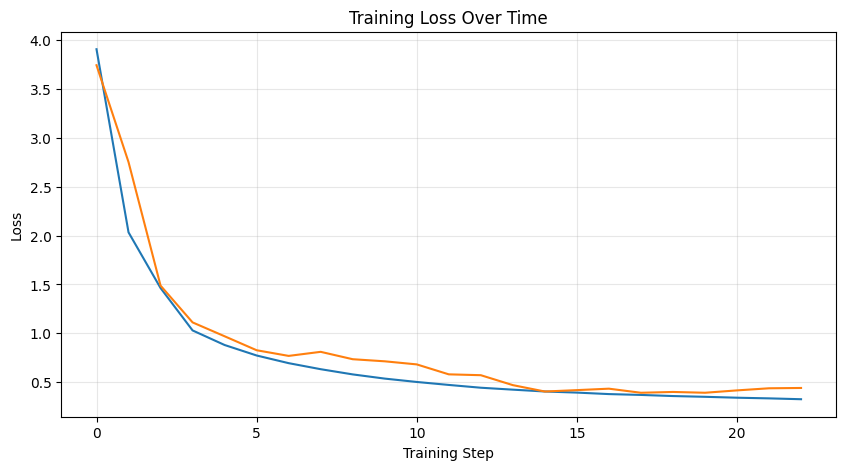


[5/6] Testing model...
Testing on 226 time steps...


Testing: 100%|██████████| 226/226 [00:46<00:00,  4.82it/s]



=== Running with seed 2 ===
Total parameters: 11,967

[4/6] Training model...
Training on 575 time steps...


Epoch 1: 100%|██████████| 575/575 [01:46<00:00,  5.37it/s]


Epoch 1: Train Loss: 4.2356 | Val Loss: 3.8888


...

Epoch 20: Train Loss: 0.3395 | Val Loss: 0.4115


Epoch 21: 100%|██████████| 575/575 [01:48<00:00,  5.31it/s]


Epoch 21: Train Loss: 0.3320 | Val Loss: 0.4118


Epoch 22: 100%|██████████| 575/575 [01:49<00:00,  5.27it/s]


Epoch 22: Train Loss: 0.3246 | Val Loss: 0.4124
Early stopping triggered


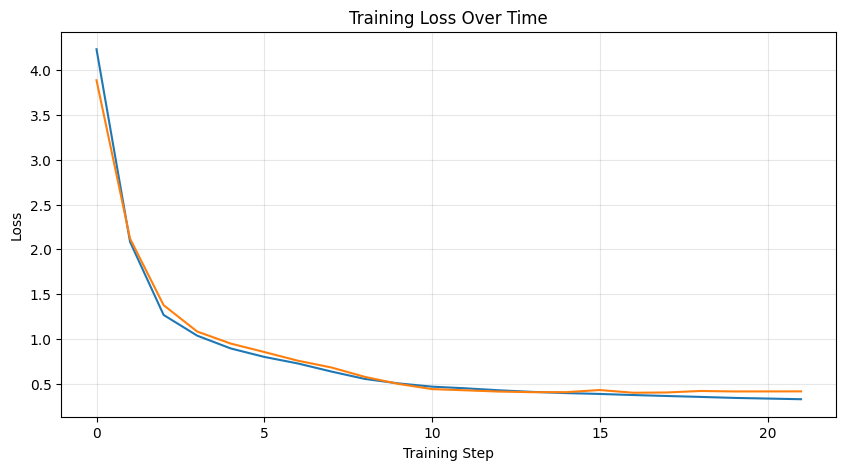


[5/6] Testing model...
Testing on 226 time steps...


Testing: 100%|██████████| 226/226 [00:45<00:00,  4.94it/s]



=== Running with seed 4 ===
Total parameters: 11,967

[4/6] Training model...
Training on 575 time steps...


Epoch 1: 100%|██████████| 575/575 [01:52<00:00,  5.13it/s]


Epoch 1: Train Loss: 4.1264 | Val Loss: 3.9265


...

Epoch 18: Train Loss: 0.3494 | Val Loss: 0.4768


Epoch 19: 100%|██████████| 575/575 [02:02<00:00,  4.71it/s]


Epoch 19: Train Loss: 0.3358 | Val Loss: 0.4741


Epoch 20: 100%|██████████| 575/575 [01:52<00:00,  5.09it/s]


Epoch 20: Train Loss: 0.3342 | Val Loss: 0.4586
Early stopping triggered


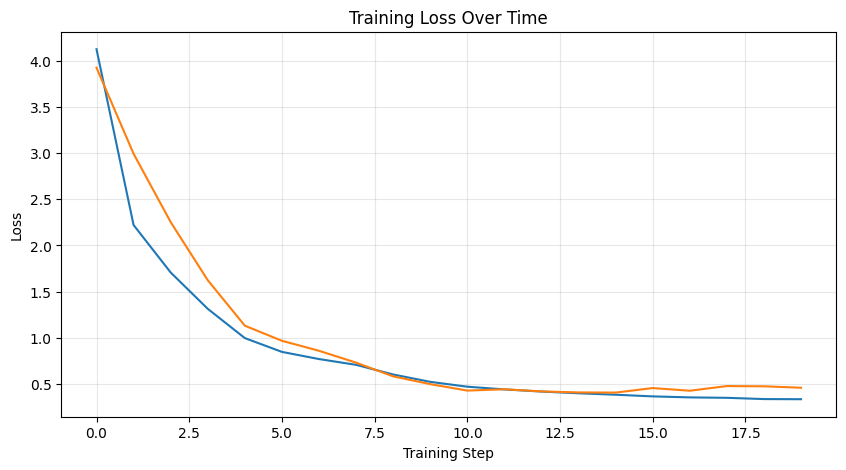


[5/6] Testing model...
Testing on 226 time steps...


Testing: 100%|██████████| 226/226 [00:46<00:00,  4.90it/s]



=== Running with seed 6 ===
Total parameters: 11,967

[4/6] Training model...
Training on 575 time steps...


Epoch 1: 100%|██████████| 575/575 [01:52<00:00,  5.12it/s]


Epoch 1: Train Loss: 4.2226 | Val Loss: 4.2939


...

Epoch 26: Train Loss: 0.3354 | Val Loss: 0.4599


Epoch 27: 100%|██████████| 575/575 [01:38<00:00,  5.82it/s]


Epoch 27: Train Loss: 0.3267 | Val Loss: 0.4366


Epoch 28: 100%|██████████| 575/575 [01:53<00:00,  5.07it/s]


Epoch 28: Train Loss: 0.3193 | Val Loss: 0.4612
Early stopping triggered


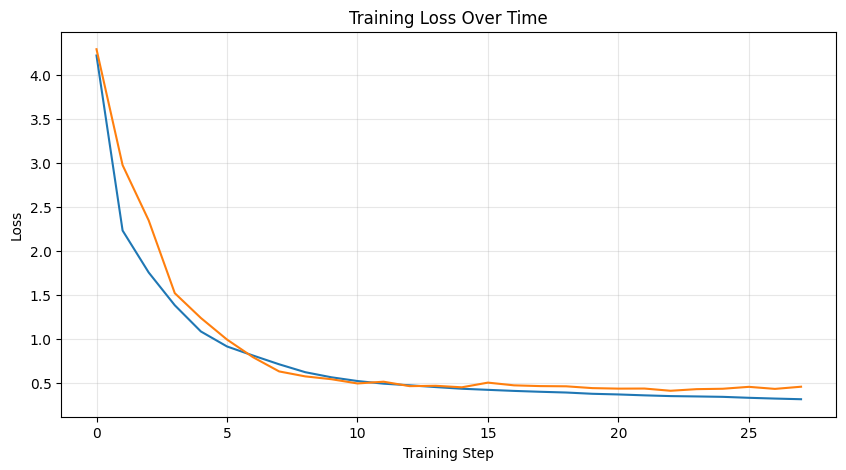


[5/6] Testing model...
Testing on 226 time steps...


Testing: 100%|██████████| 226/226 [00:47<00:00,  4.78it/s]


In [28]:

def train_model(model, optimizer, returns, volatility, Market_caps, PE_ratios, Implied_vol,
                 Beta, RSI_momentum, Turnover, Z_DATA,
                train_dates,stock2idx,patience=5,val_dates=None,embedding_cache=None, K=21, save_path='checkpoints'):

    device = next(model.parameters()).device
    #stocks = list(returns.columns)          # global universe order
    #stock2idx = {s: i for i, s in enumerate(stocks)}
    N_full = len(stock2idx)
    #stocks = list(returns.columns)
    #N = len(stocks)
    early_stopping = EarlyStopping(patience=patience, save_path=save_path)
    # Create edge index once (or you can recreate per timestamp)
    feature_dfs_list = [
    volatility, Market_caps, PE_ratios, Implied_vol,
    Beta, RSI_momentum, Turnover
    ]

    training_losses = []
    train_loss_history = []
    val_loss_history = []
    print(f"Training on {len(train_dates)} time steps...")

    for epoch in range(50):  # Multiple passes through training data
        epoch_losses = []
        #h_prev = None  # Reset hidden state each epoch
        h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
        h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
        for t in tqdm(train_dates, desc=f"Epoch {epoch+1}"):
            # Get active stocks at time t
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            if not active: continue
            returns_t = returns[active]
            stocks_t = active
            # 1. Compute PCA embeddings from returns
            node_embeddings = embedding_cache.get(t)

            # Extract embeddings for all stocks
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings:
                    emb = node_embeddings[stock]
                    if len(emb.shape) > 1 and emb.shape[0] == 1:
                        H_list.append(emb[0])  # Take first embedding
                    else:
                        H_list.append(emb)
                    #H_list.append(node_embeddings[stock][0])  # Take first embedding
                else:
                    # Default embedding
                    H_list.append(np.zeros(10))  # Assuming L=10

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)

            # 2. Compute correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
            edge_index = create_edge_index(corr_matrix, k_neighbors=10)


            # 3. Prepare node features [sector, volatility]
            X_t = prepare_node_features(stocks_t, Z_DATA, t)

            #if np.isnan(corr_matrix).any():
            #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

            # 4. Create adjacency matrix for reconstruction (optional)
            A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
            A_t_pos = A_t_pos.to(device)
            A_t_neg = A_t_neg.to(device)

            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx)
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx)
            # 5. Training step
            # loss, h_prev_pos,h_prev_neg, signals = train_step(
            #     model, optimizer, X_t, H_t, edge_index,
            #     corr_matrix_tensor, A_t_pos,A_t_neg, h_prev_pos, h_prev_neg
            # )
            model.train()
            optimizer.zero_grad()
            h_t_pos, h_t_neg, signals, loss, A_pos, A_neg = model(
                X_t, H_t, edge_index, corr_t,
                h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                A_t_pos=A_t_pos, A_t_neg=A_t_neg
            )
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Skipping NaN/Inf loss at {t}")
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # see Bug B
            optimizer.step()

            # Update full hidden states
            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()

            epoch_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            # Reset hidden states for validation sequence
            h_val_pos_full = torch.zeros(N_full, model.hidden_dim).to(device)
            h_val_neg_full = torch.zeros(N_full, model.hidden_dim).to(device)

            for t in val_dates:
                # 1. Get active stocks and features for time t
                active = get_active_stocks(returns, t, lookback_days=int(K*1.5),feature_dfs=feature_dfs_list, min_obs=K)
                if not active: continue

                returns_t = returns[active]
                stocks_t = active
                # 1. Compute PCA embeddings from returns
                node_embeddings = embedding_cache.get(t)

                # Extract embeddings for all stocks
                H_list = []
                for stock in stocks_t:
                    if stock in node_embeddings:
                        emb = node_embeddings[stock]
                        if len(emb.shape) > 1 and emb.shape[0] == 1:
                            H_list.append(emb[0])  # Take first embedding
                        else:
                            H_list.append(emb)
                        #H_list.append(node_embeddings[stock][0])  # Take first embedding
                    else:
                        # Default embedding
                        H_list.append(np.zeros(10))  # Assuming L=10

                H_t = torch.tensor(np.array(H_list), dtype=torch.float32)

                # 2. Compute correlation matrix
                corr_matrix, _ = correlation_matrix(returns_t, t, K)
                corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
                edge_index = create_edge_index(corr_matrix, k_neighbors=10)

                H_t = torch.tensor(np.array(H_list), dtype=torch.float32).to(device)
                corr_t = torch.tensor(corr_matrix, dtype=torch.float32).to(device)

                # 3. Prepare node features [sector, volatility]
                X_t = prepare_node_features(stocks_t, Z_DATA, t)

                #if np.isnan(corr_matrix).any():
                #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

                # 4. Create adjacency matrix for reconstruction (optional)
                A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
                A_t_pos = A_t_pos.to(device)
                A_t_neg = A_t_neg.to(device)

                active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
                h_val_prev_pos = h_val_pos_full.index_select(0, active_idx)
                h_val_prev_neg = h_val_neg_full.index_select(0, active_idx)

                # 2. Forward pass only
                h_t_val_pos, h_t_val_neg, _, loss, _, _ = model(X_t, H_t, edge_index, corr_t,
                                            h_prev_pos=h_val_prev_pos, h_prev_neg=h_val_prev_neg)

                h_val_pos_full[active_idx] = h_t_val_pos.detach()
                h_val_neg_full[active_idx] = h_t_val_neg.detach()

                val_losses.append(loss.item())
        #print(f"Validation Loss: {val_losses}")
        avg_train_loss = np.mean(epoch_losses)
        avg_val_loss = np.mean(val_losses) if val_losses else float('inf')

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)

        # Check Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    model.load_state_dict(torch.load(save_path))
    return model, train_loss_history, val_loss_history


def test_model(model, returns, volatility, Market_caps, PE_ratios, Implied_vol, Beta,
               RSI_momentum, Turnover,Z_DATA, embedding_cache,test_dates, stock2idx, K=21):
    device = next(model.parameters()).device
    #stocks = list(returns.columns)
    N_full = len(stock2idx)

    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)

    feature_dfs_list = [
        volatility, Market_caps, PE_ratios, Implied_vol,
        Beta, RSI_momentum, Turnover
    ]
    # Storage for results
    all_signals = []
    valid_dates = []
    active_lists = []

    print(f"Testing on {len(test_dates)} time steps...")

    for t in tqdm(test_dates, desc="Testing"):
        try:
            # 1. Compute PCA embeddings
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            #active_idx = torch.tensor([stock2idx[s] for s in active], dtype=torch.long)
            if not active:
                continue

            returns_t = returns[active]

            stocks_t    = active

            # Create edge index

            node_embeddings = embedding_cache.get(t)

            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings.keys():
                    H_list.append(node_embeddings[stock])
                else:
                    H_list.append(np.zeros(10))

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)

            # 2. Correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
            edge_index = create_edge_index(corr_matrix, k_neighbors=10)

            # 3. Node features
            X_t = prepare_node_features(stocks_t, Z_DATA, t)

            # 4. Inference
            # h_prev_pos, h_prev_neg, signals, A_pos, A_neg = inference_step(
            #     model, X_t, H_t, edge_index, corr_matrix_tensor, h_prev_pos, h_prev_neg
            # )
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx)
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx)

            with torch.no_grad():
                h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
                    X_t, H_t, edge_index, corr_t,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=None, A_t_neg=None
                )

            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()

            all_signals.append(signals.cpu().numpy())
            valid_dates.append(t)
            active_lists.append(stocks_t)

        except Exception as e:
            # FIX: Print the ACTUAL error to debug
            print(f"\n!!! Error at {t} !!!")
            traceback.print_exc()
            continue
        # except Exception as e:
        #     raise RuntimeError(f"Test failed at time {t}") from e

    # # Create results DataFrame
    # signals_array = np.array(all_signals)  # (T, N)
    # results = pd.DataFrame(
    #     signals_array,
    #     index=valid_dates,
    #     columns=stocks
    # )
    results = {d: (active_lists[i], all_signals[i]) for i, d in enumerate(valid_dates)}
    return results


def main():

    # prep data
    print("\n[1/6] Loading data...")
    device = torch.device("cpu")

    # Load prices
    prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    prices.dropna(how='all', inplace=True)
    prices = prices.ffill().bfill()
    prices.columns = prices.columns.droplevel(1)

    all_stocks = prices.columns.tolist()
    stock2idx = {s: i for i, s in enumerate(all_stocks)}
    idx2stock = {i: s for s, i in stock2idx.items()}
    N_full = len(all_stocks)

    # Load sectors
    sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors',
                            header=0, index_col=0)
    sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes


    tickers = prices.columns.get_level_values(0).unique().tolist()
    node_map = {ticker: i for i, ticker in enumerate(tickers)}

    # Split data: Train 2007-2009, Test 2019-2021
    train_prices = prices.loc[:'2007-05-30']
    test_prices = prices.loc['2007-12-31':'2008-12-31']
    val_prices = prices.loc["2007-06-01":"2007-12-30"]

    returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    returns.columns = returns.columns.get_level_values(0)
    returns.dropna(how='all', inplace=True)
    returns = returns.pct_change().dropna(how='all')
    #returns = returns.ffill().bfill()
    # Compute returns
    # train_returns = train_prices.pct_change().dropna(how='all')
    # test_returns = test_prices.pct_change().dropna(how='all')
    train_returns = returns.loc[:'2007-05-30']
    train_returns = train_returns.ffill().bfill()
    test_returns = returns.loc['2007-12-31':'2008-12-31']
    test_returns = test_returns.ffill().bfill()
    val_returns = returns.loc["2007-06-01":"2007-12-30"]
    val_dates = val_returns.index
    all_dates = sorted(set(train_returns.index) | set(test_returns.index) | set(val_returns.index))
    # Compute volatility
    train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    volatility = pd.concat([train_volatility, test_volatility]).sort_index()

    # Helper to load and fix dates
    def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
    Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

    PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

    Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

    Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
    #Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')
    #Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
    RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
    #Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
    Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')


    print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
    print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
    print(f"Number of stocks: {len(train_returns.columns)}")

    # prep trainig and testing dates
    print("\n[2/6] Preparing training dates...")

    K = 21  # Window size
    min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
    train_dates = train_returns.loc[min_date:].index

    test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
    test_dates = test_returns.loc[test_min_date:].index

    print(f"Training time steps: {len(train_dates)}")
    print(f"Testing time steps: {len(test_dates)}")

    print('Precomputing Z scores for all features...')

    def precompute_zscores(df, window=63):
        """Calculates rolling z-scores for an entire dataframe at once."""
        rolling_mean = df.rolling(window=window, min_periods=5).mean()
        rolling_std = df.rolling(window=window, min_periods=5).std()
        # Avoid division by zero with 1e-8
        z_scores = (df - rolling_mean) / (rolling_std + 1e-8)
        # Clip outliers to keep gradients stable and fill NaNs
        return z_scores.clip(-5.0, 5.0).fillna(0.0)

    # Precompute z-scores for all feature dataframes
    Z_DATA = {
        'volatility':       precompute_zscores(volatility), # use your vol_window here
        'market_caps':      precompute_zscores(Market_caps),
        'pe_ratios':        precompute_zscores(PE_ratios),
        'implied_vol':      precompute_zscores(Implied_vol),
        #'short_interest':   precompute_zscores(Short_interest),
        'beta':             precompute_zscores(Beta),
        #'op_margin':        precompute_zscores(Operating_margin),
        #'roe':              precompute_zscores(Return_on_equity),
        'rsi':              precompute_zscores(RSI_momentum),
        'turnover':         precompute_zscores(Turnover)
    }
    # initialize model
    print("\n[3/6] Initializing model...")

    # Model hyperparameters
    N = len(train_returns.columns)  # Number of stocks
    feature_dim = 7  # [volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, RSI, Turnover] TODO: try adding more features
    embedding_dim = 10  # PCA embedding dimension (L)

    gat_config = {
        'num_layers': 1,
        'heads': [2],  # Single attention head
        'features': [embedding_dim, 8]
        # Input: L=10, Output: 8
    }

    final_test_results = []

    embedding_cache = {}
    print(f"Pre-computing embeddings for {len(all_dates)} dates...")
    for t in tqdm(all_dates):
        # We reuse your existing function logic
        node_embeddings, _ = compute_initial_node_embeddings(returns, t, K)
        embedding_cache[t] = node_embeddings

    # seeds = np.random.randint(0, 10, size=3)  # Run with 3 different random seeds for robustness
    seeds = [0, 2, 4, 6]
    # for seed in seeds:
    #     torch.manual_seed(seed)
    #     np.random.seed(seed)
    #     print(f'\n=== Running with seed {seed} ===')
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f'\n=== Running with seed {seed} ===')
        model = BubbleDetectionModel(
            gat_config=gat_config,
            feature_dim=feature_dim,
            embedding_dim=embedding_dim,
            encoder_channels=[16, 8],  # Spatial encoder: 2 -> 16 -> 8
            hidden_dim=32,  # GRU hidden dimension
            num_diffusion_steps=1,
            use_structure_recon=True,
            dropout=0.1
        )

        optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-05)

        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")

        # training
        print("\n[4/6] Training model...")

        # Create output directory
        os.makedirs('outputs', exist_ok=True)

        # model, training_losses, val_losses = train_model(
        #     model, optimizer, returns, sectors, train_volatility, Market_caps, PE_ratios, Implied_vol,
        #     Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, Z_DATA,
        #     train_dates, stock2idx, patience=5, val_dates=val_dates, embedding_cache=embedding_cache, K=K, save_path='outputs/bubble_model.pt'
        # )
        model, training_losses, val_losses = train_model(
            model, optimizer, returns, train_volatility, Market_caps, PE_ratios, Implied_vol,
            Beta, RSI_momentum, Turnover, Z_DATA,
            train_dates, stock2idx, patience=5, val_dates=val_dates, embedding_cache=embedding_cache, K=K, save_path='outputs/bubble_model.pt'
        )


        # Plot training loss
        plt.figure(figsize=(10, 5))
        plt.plot(training_losses)
        plt.plot(val_losses)
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Time')
        plt.grid(alpha=0.3)
        plt.savefig('outputs/training_loss.png', dpi=300, bbox_inches='tight')
        plt.show()

        # testing
        print("\n[5/6] Testing model...")

        #test_results = test_model(model, test_returns, sectors, test_volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta,
        #            Operating_margin, Return_on_equity, RSI_momentum, Turnover, Z_DATA, embedding_cache, test_dates, stock2idx, K=21) # d:(active_stocks, signals_array)
        test_results = test_model(model, test_returns, test_volatility, Market_caps, PE_ratios, Implied_vol, Beta,
                    RSI_momentum, Turnover, Z_DATA, embedding_cache, test_dates, stock2idx, K=21)
    # test_results is a dict: {date: [(active_stocks, signals_array), ...]}
    #final_test_results.append(test_results)
    #print(f"Average bubble signal: {test_results.mean().mean():.4f}")
    #print(f"Max bubble signal: {test_results.max().max():.4f}")
    # i want average signals in final test results
        final_test_results.append(test_results)
    # now do mean signals across different seeds for each date and stock
    #final_test_results is a list of dicts: [{date: (active_stocks, signals)}, ...]
    # we want to average signals for the same date and stock across different
    final_test_results_dict = {} # date: (stocks, avg_signals)
    for test_result in final_test_results:
        for date, (stocks, signals) in test_result.items():
            if date not in final_test_results_dict:
                final_test_results_dict[date] = (stocks, [signals])
            else:
                final_test_results_dict[date][1].append(signals)
    # Now average signals for each date and stock
    for date, (stocks, signals_list) in final_test_results_dict.items():
        avg_signals = np.mean(signals_list, axis=0)  # Average across seeds
        final_test_results_dict[date] = (stocks, avg_signals)
    # Save results
    pd.to_pickle(final_test_results_dict, f"outputs/test_results_test_11Apr_best_2005.pkl")
    pd.to_pickle(test_prices, f"outputs/test_prices_test_11Apr_best_2005.pkl")
    return final_test_results_dict, test_prices

if __name__ == "__main__":
    test_results, test_prices = main()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("[5] Visualizing Average Anomaly Signal (Regression Baseline)...")

# 1. Convert the dictionary results into a pandas Series of average scores
# reg_results structure: {date: (active_stocks_list, probabilities_array)}
date_map = {}
test_results = pd.read_pickle('outputs/test_results_test_11Apr_best_2005.pkl')

for date, (stocks, probs) in test_results.items():
    # We take the mean of the probabilities for that specific day
    date_map[date] = np.mean(probs)

# Create a Series sorted by date
avg_signals = pd.Series(date_map).sort_index()

# 2. Filter for 2020
try:
    # Slice the series for the year 2020
    avg_signals_2020 = avg_signals.loc['2020-01-01':'2021-01-01']
except KeyError:
    print("Warning: Date range not found in data.")
    avg_signals_2020 = pd.Series()

# 3. Plot
if not avg_signals_2020.empty:
    plt.figure(figsize=(12, 6))

    # Plot directly using the index (dates) and values
    plt.plot(avg_signals_2020.index, avg_signals_2020.values, color='blue', linewidth=2, label='Avg')
    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'),
                color='grey', alpha=0.3, label='COVID Crash')

    plt.title("GAE Anomaly Detection")
    plt.ylabel("Average Crash Probability")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")

[5] Visualizing Average Anomaly Signal (Regression Baseline)...
No data found for 2020.


In [30]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# fig, ax1 = plt.subplots(figsize=(14, 5))

# market_data = pd.read_excel('Data/Market_SPX.xlsx', header=0, index_col=0)
# market_data_test = market_data.loc['2020-01-01':'2023-12-31']
# spx = market_data_test.iloc[:, 0]

# date_map = {}
# test_results = pd.read_pickle('outputs/test_results_test_11Apr_fix2_diff2.pkl')

# for date, (stocks, probs) in test_results.items():
#     # We take the mean of the probabilities for that specific day
#     date_map[date] = np.mean(probs)

# # Create a Series sorted by date
# avg_signals = pd.Series(date_map).sort_index()
# avg_signals = avg_signals.loc['2020-01-01':'2023-12-31']

# ax1.set_xlabel("Date")
# ax1.set_ylabel("Mean Anomaly Signal", color="steelblue")
# ax1.plot(avg_signals.index, avg_signals.values, color="steelblue", linewidth=1.2, label="Mean anomaly signal")
# ax1.tick_params(axis="y", labelcolor="steelblue")

# ax2 = ax1.twinx()
# ax2.set_ylabel("SPX Level", color="firebrick")
# ax2.plot(spx.index, spx.values, color="firebrick", linewidth=1.2, alpha=0.7, label="SPX")
# ax2.tick_params(axis="y", labelcolor="firebrick")

# # Shade known crash periods
# crashes = [
#     ("COVID-19",  "2020-02-20", "2020-03-23"),
#     ("2022 Bear", "2022-01-03", "2022-10-12"),
# ]
# for label, start, end in crashes:
#     ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="grey", alpha=0.2, label=label)

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
# plt.title("PCA Mean Anomaly Signal vs SPX Index (2019–2024)")
# plt.tight_layout()
# plt.show()

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import torch


def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks, signals = test_results[t]

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]

        signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int)

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean() # 

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline, precision

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline, precision = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
                f"Baseline={baseline:.2f}"
                f"Precision={precision:.2f}"
            )

    return pd.DataFrame(rows)


In [32]:
forward_windows = [10,22]

crash_thresholds = [-0.10,-0.15,-0.20,-0.30]

test_results = pd.read_pickle("outputs/test_results_test_11Apr_best_2005.pkl")

test_prices = pd.read_pickle("outputs/test_prices_test_11Apr_best_2005.pkl")

df_results = grid_search(

    test_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW= 10 CT= -0.10 AUC=0.617 Lift=2.21Baseline=0.12Precision=0.28
FW= 10 CT= -0.15 AUC=0.658 Lift=2.73Baseline=0.06Precision=0.17
FW= 10 CT= -0.20 AUC=0.679 Lift=3.11Baseline=0.03Precision=0.10
FW= 10 CT= -0.30 AUC=0.686 Lift=3.34Baseline=0.01Precision=0.03
FW= 22 CT= -0.10 AUC=0.597 Lift=1.75Baseline=0.22Precision=0.38
FW= 22 CT= -0.15 AUC=0.639 Lift=2.15Baseline=0.13Precision=0.29
FW= 22 CT= -0.20 AUC=0.673 Lift=2.50Baseline=0.08Precision=0.21
FW= 22 CT= -0.30 AUC=0.701 Lift=2.81Baseline=0.03Precision=0.08


In [33]:
# # GAE training on 2005-2007, testing on 2008, 2 diff steps : 
# FW= 10 CT= -0.10 AUC=0.622 Lift=2.21Baseline=0.12Precision=0.27
# FW= 10 CT= -0.15 AUC=0.666 Lift=2.67Baseline=0.06Precision=0.16
# FW= 10 CT= -0.20 AUC=0.687 Lift=3.00Baseline=0.03Precision=0.09
# FW= 10 CT= -0.30 AUC=0.693 Lift=3.24Baseline=0.01Precision=0.03
# FW= 22 CT= -0.10 AUC=0.596 Lift=1.73Baseline=0.22Precision=0.38
# FW= 22 CT= -0.15 AUC=0.640 Lift=2.12Baseline=0.13Precision=0.28
# FW= 22 CT= -0.20 AUC=0.676 Lift=2.44Baseline=0.08Precision=0.21
# FW= 22 CT= -0.30 AUC=0.703 Lift=2.76Baseline=0.03Precision=0.08